# Batch Prediction for Image Datasets

This notebook shows how to use `predict_from_batch` to cloud mask many same-sized images at once, for example the chips of an existing training dataset that you want to filter for clouds. It walks through each input type and output option:

| Section | Input | Output |
|---|---|---|
| 2 | 4D numpy array | class masks |
| 3 | list of arrays | class masks |
| 4 | generator | class masks |
| 5 | torch tensor on the GPU | class masks |
| 6 | 4D numpy array | confidence maps |
| 7 | file paths + `load_func` | class masks |
| 8 | file paths + `load_func` | GeoTIFFs on disk |

It then shows how to filter the dataset by cloud cover, how to handle a missing NIR band, and what to do with chips of different sizes.

As a stand-in for your own dataset, a helper downloads a Sentinel-2 L2A scene from the [Microsoft Planetary Computer](https://planetarycomputer.microsoft.com/dataset/sentinel-2-l2a) and cuts it into 512×512 chips.

**Extra dependencies:**
```
pip install pystac-client planetary-computer
```

In [1]:
import time
from functools import partial
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rasterio as rio
import torch

from batch_prediction_helpers import load_chip_dataset, show_chips
from omnicloudmask import load_multiband, predict_from_batch

## 1. Load the chip dataset

`load_chip_dataset` returns:
- `chips`: a `(N, 3, 512, 512)` array in **Red, Green, NIR** order, the layout `predict_from_batch` expects
- `rgb_chips`: the matching true-colour chips, only used for plotting
- `chip_paths`: the same chips saved as georeferenced GeoTIFFs, for the file-based examples

The chips are cached in `Batch data/`, so later runs skip the download. With your own dataset, you would load your chips here instead.

Loaded 25 chips of 512x512 px
chips: (25, 3, 512, 512) uint16


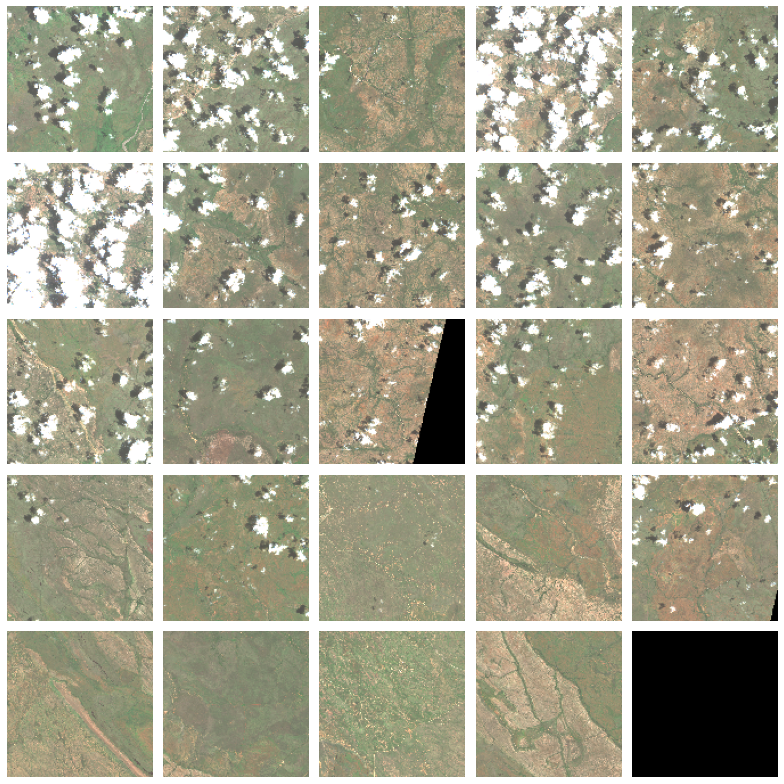

In [2]:
chips, rgb_chips, chip_paths = load_chip_dataset(Path.cwd() / "Batch data")
print(f"chips: {chips.shape} {chips.dtype}")
show_chips(rgb_chips)

`show_chips` overlays the non-clear classes at 50% opacity: thick cloud in orange, thin cloud in green, cloud shadow in red.

## 2. Input: 4D numpy array

The simplest case: pass the whole `(N, 3, H, W)` array. `batch_size` sets how many chips go through the model together. Larger batches are faster on a GPU, up to the limit of your GPU memory.

The output is a `(N, 1, H, W)` uint8 array: 0 = clear, 1 = thick cloud, 2 = thin cloud, 3 = cloud shadow.

Running inference using cuda float32:   0%|          | 0/25 [00:00<?, ?it/s]

masks: (25, 1, 512, 512) uint8


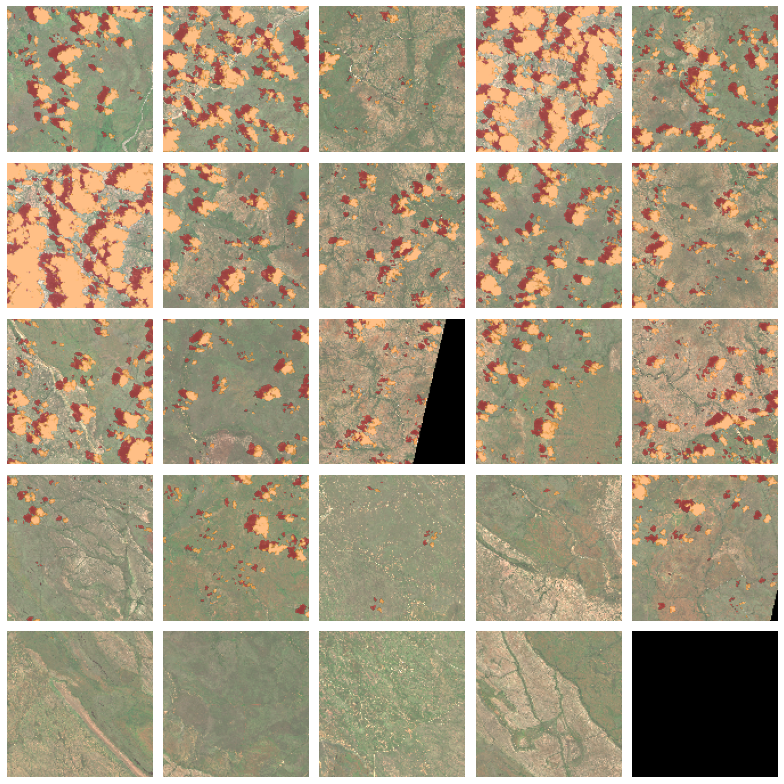

In [3]:
masks = predict_from_batch(chips, batch_size=8)
print(f"masks: {masks.shape} {masks.dtype}")
show_chips(rgb_chips, masks)

## 3. Input: list of arrays

Any iterable of `(3, H, W)` arrays works. All images in one call must have the same shape.

In [4]:
chip_list = list(chips)
masks_from_list = predict_from_batch(chip_list, batch_size=8)
print(f"Same as the array input: {np.array_equal(masks_from_list, masks)}")

Running inference using cuda float32:   0%|          | 0/25 [00:00<?, ?it/s]

Same as the array input: True


## 4. Input: generator

A generator is consumed lazily, a few batches ahead of the model, so the full dataset never has to fit in memory as input. The progress bar shows a count instead of a total, because a generator has no length.

In [5]:
def chip_generator():
    for chip in chips:
        yield chip


masks_from_generator = predict_from_batch(chip_generator(), batch_size=8)
print(f"Same as the array input: {np.array_equal(masks_from_generator, masks)}")

Running inference using cuda float32: 0it [00:00, ?it/s]

Same as the array input: True


## 5. Input: torch tensor

Tensors work too, including tensors already on the GPU, which skips the copy from host memory.

In [6]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

chip_tensor = torch.from_numpy(chips.astype(np.float32)).to(device)
masks_from_tensor = predict_from_batch(
    chip_tensor, batch_size=8, inference_device=device
)
agreement = (masks_from_tensor == masks).mean()
print(f"Tensor on {device}: {agreement:.2%} of pixels match the array input")

Running inference using cuda float32:   0%|          | 0/25 [00:00<?, ?it/s]

Tensor on cuda: 100.00% of pixels match the array input


## 6. Output: confidence maps

`export_confidence=True` returns per-class probabilities with shape `(N, 4, H, W)` instead of class indices. Set `softmax_output=False` to get the raw model outputs instead.

Running inference using cuda float32:   0%|          | 0/25 [00:00<?, ?it/s]

confidence: (25, 4, 512, 512) float32


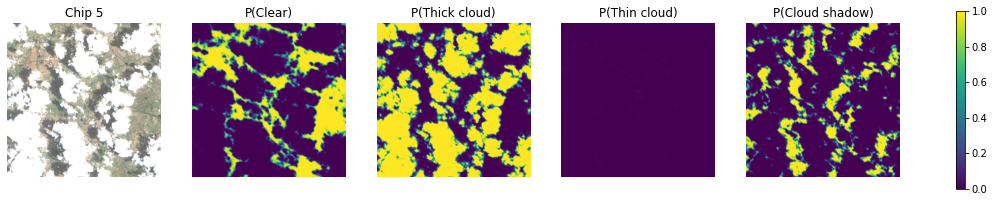

In [7]:
confidence = predict_from_batch(chips, batch_size=8, export_confidence=True)
print(f"confidence: {confidence.shape} {confidence.dtype}")

# Show the chip with the most thick cloud
cloudiest = int(np.argmax((masks == 1).sum(axis=(1, 2, 3))))
class_names = ["Clear", "Thick cloud", "Thin cloud", "Cloud shadow"]

fig, axes = plt.subplots(1, 5, figsize=(20, 4), dpi=72)
axes[0].imshow(np.clip(rgb_chips[cloudiest] / 3000, 0, 1).transpose(1, 2, 0))
axes[0].set_title(f"Chip {cloudiest}")
for ax, name, probability in zip(axes[1:], class_names, confidence[cloudiest]):
    im = ax.imshow(probability, vmin=0, vmax=1, cmap="viridis")
    ax.set_title(f"P({name})")
for ax in axes:
    ax.axis("off")
fig.colorbar(im, ax=axes, shrink=0.8)
plt.show()

## 7. Input: file paths with `load_func`

When your dataset is on disk, pass a list of file paths and a `load_func`. Each path is passed as `load_func(input_path=path)`, so the built-in loaders work directly. Files are loaded in background threads while the model runs.

`load_func` must return a `(3, H, W)` array, or an `(array, rasterio profile)` tuple like the built-in loaders.

In [8]:
loader = partial(load_multiband, band_order=[1, 2, 3])  # bands 1-3 are R, G, NIR
masks_from_files = predict_from_batch(chip_paths, batch_size=8, load_func=loader)
print(f"Same as the array input: {np.array_equal(masks_from_files, masks)}")

Running inference using cuda float32:   0%|          | 0/25 [00:00<?, ?it/s]

Same as the array input: True


## 8. Output: GeoTIFFs with `export_to_disk`

With `export_to_disk=True`, each prediction is written as a GeoTIFF using the profile from `load_func`, so the masks keep the chips' georeferencing. The function returns the output paths instead of an array, so large datasets never need to fit in memory.

Masks are saved next to the inputs unless you set `output_dir`.

In [9]:
mask_dir = Path.cwd() / "Batch data" / "masks"
mask_paths = predict_from_batch(
    chip_paths,
    batch_size=8,
    load_func=loader,
    export_to_disk=True,
    output_dir=mask_dir,
)
print(f"Wrote {len(mask_paths)} masks, e.g. {mask_paths[0].name}")

with rio.open(chip_paths[0]) as chip_src, rio.open(mask_paths[0]) as mask_src:
    print(f"Chip transform matches mask: {chip_src.transform == mask_src.transform}")
    print(f"Chip CRS matches mask: {chip_src.crs == mask_src.crs}")

Running inference using cuda float32:   0%|          | 0/25 [00:00<?, ?it/s]

Wrote 25 masks, e.g. chip_512_000_OCM_v1_7_1.tif
Chip transform matches mask: True
Chip CRS matches mask: True


With `overwrite=False`, chips that already have a mask are skipped, so an interrupted run can be restarted where it stopped. Here every mask exists, so nothing is loaded or predicted.

In [10]:
start = time.perf_counter()
mask_paths = predict_from_batch(
    chip_paths,
    batch_size=8,
    load_func=loader,
    export_to_disk=True,
    output_dir=mask_dir,
    overwrite=False,
)
print(f"Returned {len(mask_paths)} paths in {time.perf_counter() - start:.2f}s")

Returned 25 paths in 0.00s


## 9. Filter the dataset by cloud cover

A typical use is dropping cloudy chips from a dataset. No-data pixels come back as 0, which is also the Clear class, so compute the cloud fraction over valid pixels only. Chips that are mostly no data, like those at the edge of the satellite swath, are also dropped, otherwise an empty chip would count as 0% cloud.

In [11]:
NO_DATA_VALUE = 0
MAX_CLOUD_FRACTION = 0.05
MIN_VALID_FRACTION = 0.9

valid = ~np.all(chips == NO_DATA_VALUE, axis=1, keepdims=True)
valid_pixels = valid.sum(axis=(1, 2, 3))
cloudy = np.isin(masks, [1, 2, 3]) & valid  # thick cloud, thin cloud, shadow
cloud_fraction = cloudy.sum(axis=(1, 2, 3)) / np.maximum(valid_pixels, 1)
valid_fraction = valid_pixels / valid[0].size

keep = (cloud_fraction < MAX_CLOUD_FRACTION) & (valid_fraction >= MIN_VALID_FRACTION)
print(f"Keeping {keep.sum()} of {len(chips)} chips")

Keeping 8 of 25 chips


Kept


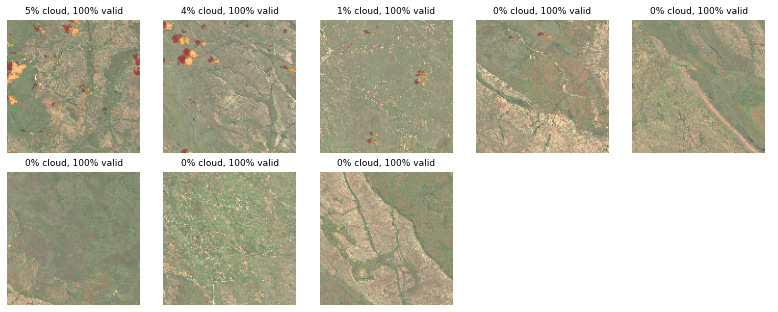

Removed


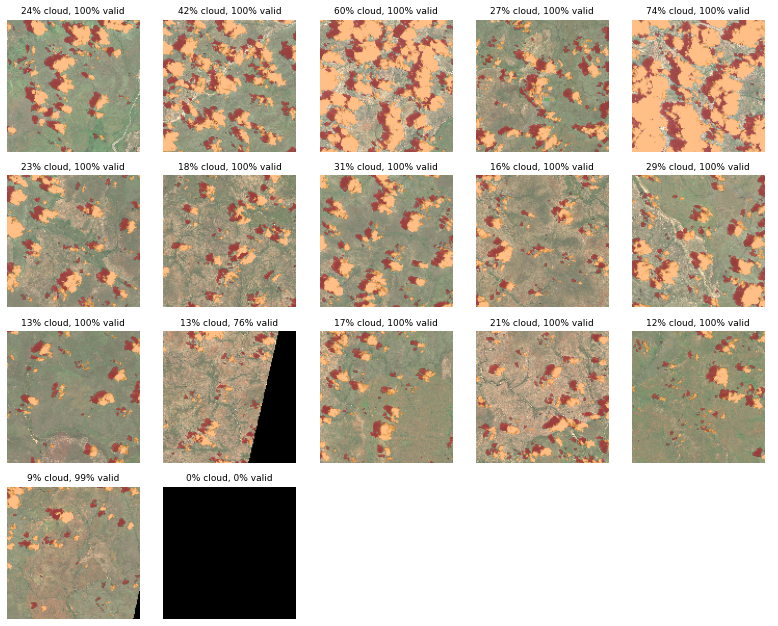

In [12]:
titles = [
    f"{cloud:.0%} cloud, {valid:.0%} valid"
    for cloud, valid in zip(cloud_fraction, valid_fraction)
]

print("Kept")
show_chips(rgb_chips[keep], masks[keep], [t for t, k in zip(titles, keep) if k])
print("Removed")
show_chips(rgb_chips[~keep], masks[~keep], [t for t, k in zip(titles, keep) if not k])

## 10. Missing NIR band

If your dataset has no NIR band, fill that channel with zeros. The model still gives useful masks from Red and Green alone, though NIR helps.

In [13]:
chips_without_nir = chips.copy()
chips_without_nir[:, 2] = 0

masks_without_nir = predict_from_batch(chips_without_nir, batch_size=8)
agreement = (masks_without_nir == masks).mean()
print(f"{agreement:.2%} of pixels match the prediction with NIR")

Running inference using cuda float32:   0%|          | 0/25 [00:00<?, ?it/s]

98.26% of pixels match the prediction with NIR


## 11. Chips of different sizes

All images in one call must have the same shape. If your dataset has several chip sizes, group them by size and call `predict_from_batch` once per group. The models stay cached between calls.

Very small chips give the model little spatial context, which lowers accuracy. See the [spatial context](https://omnicloudmask.readthedocs.io/en/latest/spatial-context.html) page.

In [14]:
small_chips = chips[:, :, :256, :256]  # e.g. a second set of 256x256 chips

masks_by_size = {}
for group in [chips, small_chips]:
    size = group.shape[-1]
    masks_by_size[size] = predict_from_batch(group, batch_size=8)

for size, group_masks in masks_by_size.items():
    print(f"{size}x{size}: {group_masks.shape}")

Running inference using cuda float32:   0%|          | 0/25 [00:00<?, ?it/s]

Running inference using cuda float32:   0%|          | 0/25 [00:00<?, ?it/s]

512x512: (25, 1, 512, 512)
256x256: (25, 1, 256, 256)
